### Détection de la pneumonie à partir de radiographies thoraciques:
Présente par : SAID Myra, BENGASSINE Mahmoud, HADDAB Wilem, Tarek AbdelDjalil. 

Dataset trouvé : chest_xray
Sous-dossiers : ['chest_xray', 'test', 'train', 'val', '__MACOSX']

===== NOMBRE D'IMAGES =====
split  label    
test   NORMAL        234
       PNEUMONIA     390
train  NORMAL       1341
       PNEUMONIA    3875
val    NORMAL          8
       PNEUMONIA       8
dtype: int64

===== FORMATS =====
format
JPEG    5856
Name: count, dtype: int64

===== MODES =====
mode
L      5573
RGB     283
Name: count, dtype: int64

===== TAILLES =====
             width       height
count  5856.000000  5856.000000
mean   1327.880806   970.689037
std     363.500922   383.392117
min     384.000000   127.000000
25%    1056.000000   688.000000
50%    1281.000000   888.000000
75%    1560.000000  1187.000000
max    2916.000000  2713.000000

===== IMAGES CORROMPUES =====
0


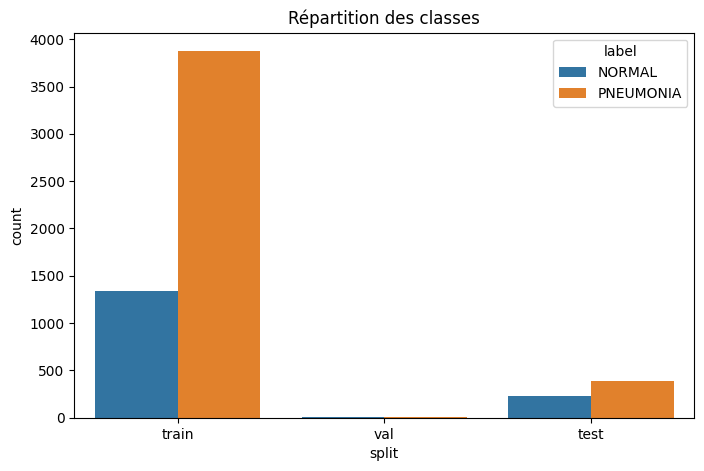

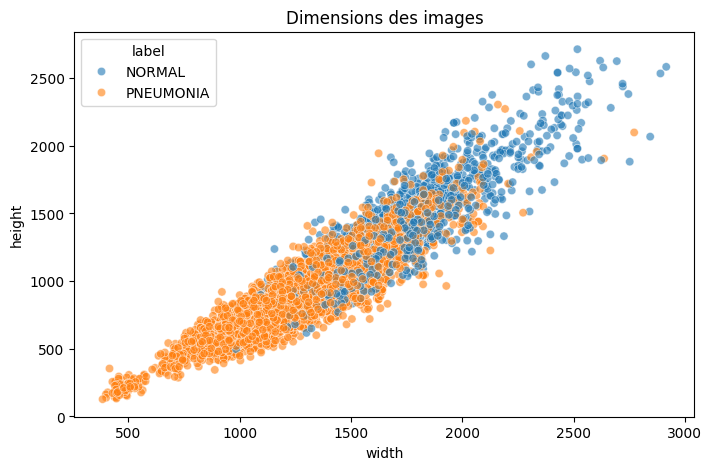


===== DOUBLONS =====
0

===== RESUME =====
Total images : 5856


In [1]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "chest_xray"   # adapte ici

# Vérifier dossier principal
if not os.path.exists(dataset_path):
    print("Dossier introuvable :", dataset_path)
    print("Contenu actuel :", os.listdir())
else:
    print("Dataset trouvé :", dataset_path)
    print("Sous-dossiers :", os.listdir(dataset_path))

data = []
corrupted_files = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    if not os.path.exists(split_path):
        print(f"{split} absent")
        continue

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)

        if not os.path.isdir(label_path):
            continue

        for file in os.listdir(label_path):
            file_path = os.path.join(label_path, file)

            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    fmt = img.format
                    mode = img.mode

                data.append({
                    "split": split,
                    "label": label,
                    "file": file,
                    "width": width,
                    "height": height,
                    "format": fmt,
                    "mode": mode
                })

            except:
                corrupted_files.append(file_path)

# DataFrame
df = pd.DataFrame(data)

# Vérifier si vide
if df.empty:
    print("Aucune image chargée.")
else:
    print("\n===== NOMBRE D'IMAGES =====")
    print(df.groupby(["split", "label"]).size())

    print("\n===== FORMATS =====")
    print(df["format"].value_counts())

    print("\n===== MODES =====")
    print(df["mode"].value_counts())

    print("\n===== TAILLES =====")
    print(df[["width", "height"]].describe())

    print("\n===== IMAGES CORROMPUES =====")
    print(len(corrupted_files))

    # Graphique classes
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x="split", hue="label")
    plt.title("Répartition des classes")
    plt.show()

    # Dimensions
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x="width", y="height", hue="label", alpha=0.6)
    plt.title("Dimensions des images")
    plt.show()

    duplicates = df.duplicated(subset=["file"]).sum()

    print("\n===== DOUBLONS =====")
    print(duplicates)

    print("\n===== RESUME =====")
    print("Total images :", len(df))

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)


### Configuration générale

Cette section définit les paramétres principaux du projet : chemin du dataset, taille des images, batch size, nombre maximal d'epochs, seuil de décision et périphérique utilisé (`CPU` ou `GPU`).

Les images sont redimensionnées en `128x128`, une taille carrée et puissance de 2 (`128 = 2^7`). Ce choix est un compromis entre conservation des détails médicaux et temps d'entraénement raisonnable.


In [14]:
DATA_DIR    = "./chest_xray"
IMG_SIZE    = 128              
BATCH_SIZE  = 32               
EPOCHS      = 15               
LR          = 1e-3
DECISION_THRESHOLD = 0.55      
EARLY_STOPPING_PATIENCE = 7   
MIN_DELTA   = 0.001
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY  = DEVICE.type == "cuda"

print(f"Device utilisé : {DEVICE}")
print(f"Taille des images : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Seuil de décision : {DECISION_THRESHOLD}")


Device utilisé : cpu
Taille des images : 128x128
Batch size : 32
Seuil de décision : 0.55


### 1. Transformation et augmentation des images

Les images sont transformées avant d'étre envoyées au modéle. Pour l'entrannement, une légére augmentation est appliquée afin d'améliorer la généralisation du CNN. Pour la validation et le test, aucune augmentation aléatoire n'est utilisée afin d'évaluer le modéle de maniére stable.

Toutes les images sont converties en tenseurs puis normalisées.


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),
])


### 2. Chargement des données

Le dataset est organisé avec `ImageFolder`, ce qui permet de charger automatiquement les classes à partir des dossiers `NORMAL` et `PNEUMONIA`.

Les données sont séparées en trois ensembles :

- `train` : utilisé pour apprendre les paramétres du modéle.
- `val` : utilisé pendant l'entraénement pour surveiller la généralisation.
- `test` : utilisé uniquement à la fin pour évaluer les performances finales.


In [6]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"), transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"), transform=eval_transforms
)
test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=eval_transforms
)
 
# Affiche la distribution des classes
print("\n Distribution du dataset :")
for split, ds in [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]:
    counts = np.bincount([label for _, label in ds])
    print(f"  {split:5s} → NORMAL: {counts[0]:4d} | PNEUMONIA: {counts[1]:4d}  "
          f"(ratio 1:{counts[1]/counts[0]:.1f})")


 Distribution du dataset :
  Train → NORMAL: 1341 | PNEUMONIA: 3875  (ratio 1:2.9)
  Val   → NORMAL:    8 | PNEUMONIA:    8  (ratio 1:1.0)
  Test  → NORMAL:  234 | PNEUMONIA:  390  (ratio 1:1.7)


### 3. Gestion du déséquilibre des classes

Le dataset contient plus d'images `PNEUMONIA` que d'images `NORMAL`. Pour limiter ce déséquilibre pendant l'entraénement, j'utilise un `WeightedRandomSampler`.

Le principe est de donner plus de poids aux images de la classe minoritaire afin que les batchs soient plus équilibrés.


In [7]:
# Stratégie : sur-échantillonner la classe minoritaire (NORMAL) lors du chargement.
labels = [label for _, label in train_dataset]
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Sur Windows + notebook, num_workers=0 ?vite souvent des blocages/lenteurs.
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"\nDataloaders créés - {len(train_loader)} batchs d entrainement")



Dataloaders créés - 163 batchs d entrainement


Un batch est un petit groupe d'images traité en meme temps par le modéle. Au lieu d'apprendre image par image, le réseau apprend sur plusieurs images à la fois, ce qui rend l'entraénement plus stable.


Le sampling correspond à la manière dont les images sont sélectionnées pour former les batchs. Ici, il est utilisé pour réduire l'effet du déséquilibre entre les classes `NORMAL` et `PNEUMONIA`.


### 4. Architecture du CNN

Le modèle utilisé est un CNN entrainé from scratch. Il contient plusieurs blocs convolutionnels pour extraire les caractéristiques visuelles des radios, puis un classifieur final qui produit une seule sortie.

Cette sortie est un logit binaire : aprés application d'une sigmoid, elle représente la probabilité que l'image appartienne à la classe `PNEUMONIA`.


In [9]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

model = PneumoniaCNN().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nMod?le l?ger : {total_params:,} param?tres entra?nables")



Mod?le l?ger : 89,473 param?tres entra?nables


### 5. Fonction de perte, optimiseur et scheduler

La fonction de perte utilisée est la `FocalLoss`, adaptée aux problèmes où les classes sont déséquilibrées. Elle permet au modèle de se concentrer davantage sur les exemples difficiles.

L'optimiseur `Adam` met à jour les poids du modèle. Le scheduler réduit le learning rate lorsque la `val_loss` stagne, ce qui aide à stabiliser l'entraénement.


In [10]:
criterion = FocalLoss(alpha=0.75, gamma=2.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# On baisse le learning rate quand la val_loss stagne.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=7,
)


### 6. Boucle d'entrainement

La boucle d'entrainement calcule la perte et l'accuracy sur le train et la validation à chaque epoch.

L'early stopping surveille la `val_loss`. Si elle ne s'améliore plus pendant plusieurs epochs, l'entrainement s'arréte automatiquement. Le meilleur modèle est sauvegardé dans `best_pneumonia_model.pth`.


Les résultats retenus ont été obtenus avec `IMG_SIZE = 128`, plus léger que `256x256`, tout en gardant suffisamment d'information visuelle pour détecter les signes de pneumonie.


In [15]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE, threshold=DECISION_THRESHOLD):
    """Une epoch d entra?nement ou d ?valuation."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # (B, 1)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = (torch.sigmoid(logits) >= threshold).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_val_acc = 0.0
best_epoch = 0
patience_counter = 0

print("\nEntrainement démarré...\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, threshold=DECISION_THRESHOLD)
    v_loss, v_acc = run_epoch(model, val_loader, criterion, threshold=DECISION_THRESHOLD)
    scheduler.step(v_loss)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    improved = v_loss < best_val_loss - MIN_DELTA
    marker = " *" if improved else ""

    if improved:
        best_val_loss = v_loss
        best_val_acc = v_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), "best_pneumonia_model.pth")
    else:
        patience_counter += 1

    print(f"{epoch:5d} | {t_loss:10.4f} | {t_acc:9.4f} | {v_loss:8.4f} | {v_acc:8.4f}{marker}")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping activé à l epoch {epoch} : val_loss sans amélioration depuis {EARLY_STOPPING_PATIENCE} epochs.")
        break

model.load_state_dict(torch.load("best_pneumonia_model.pth", map_location=DEVICE))
print(f"\nMeilleur modèle : epoch {best_epoch} - val_loss = {best_val_loss:.4f}, val_acc = {best_val_acc:.4f}")



Entrainement démarré...

Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
    1 |     0.0280 |    0.9440 |   0.2330 |   0.8125 *
    2 |     0.0264 |    0.9498 |   0.0898 |   0.8125 *
    3 |     0.0218 |    0.9576 |   0.0932 |   0.8750
    4 |     0.0194 |    0.9628 |   0.1841 |   0.7500
    5 |     0.0237 |    0.9549 |   0.0860 |   0.8125 *
    6 |     0.0196 |    0.9624 |   0.1695 |   0.7500
    7 |     0.0156 |    0.9709 |   0.1187 |   0.8125
    8 |     0.0175 |    0.9663 |   0.0651 |   0.9375 *
    9 |     0.0146 |    0.9749 |   0.1122 |   0.8125
   10 |     0.0144 |    0.9739 |   0.0700 |   0.8750
   11 |     0.0137 |    0.9760 |   0.0543 |   0.9375 *
   12 |     0.0146 |    0.9716 |   0.1230 |   0.7500
   13 |     0.0156 |    0.9712 |   0.0595 |   0.9375
   14 |     0.0132 |    0.9747 |   0.1127 |   0.7500
   15 |     0.0148 |    0.9705 |   0.0502 |   0.8750 *

Meilleur modèle : epoch 15 - val_loss = 0.0502, val_acc =

### 7. Evaluation sur le test set

Aprés l'entrainement, le meilleur modèle sauvegardé est rechargé puis évalué sur le test set.

Les métriques importantes sont le rapport de classification, la matrice de confusion et l'AUC-ROC. En contexte médical, le rappel de la classe `PNEUMONIA` est particulièrement important, car manquer une pneumonie est plus grave que classer une image normale comme suspecte.


In [16]:
model.load_state_dict(torch.load("best_pneumonia_model.pth", map_location=DEVICE))
model.eval()
 
all_labels, all_probs = [], []
 
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
threshold = DECISION_THRESHOLD
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= threshold).astype(int)
 
print("\nRapport de classification (test set) :")
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "PNEUMONIA"]))
 
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC-ROC : {auc:.4f}")



Rapport de classification (test set) :
              precision    recall  f1-score   support

      NORMAL       0.93      0.47      0.63       234
   PNEUMONIA       0.76      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.73      0.74       624
weighted avg       0.82      0.79      0.77       624

AUC-ROC : 0.9342


### 8. Visualisation des résultats

Les graphiques permettent d'analyser le comportement du modèle :

- Les courbes de loss montrent l'évolution de l'erreur pendant l'entrainement.
- Les courbes d'accuracy montrent la proportion de bonnes prédictions.
- La matrice de confusion montre les erreurs par classe.
- La courbe ROC mesure la capacité du modèle à séparer les classes.


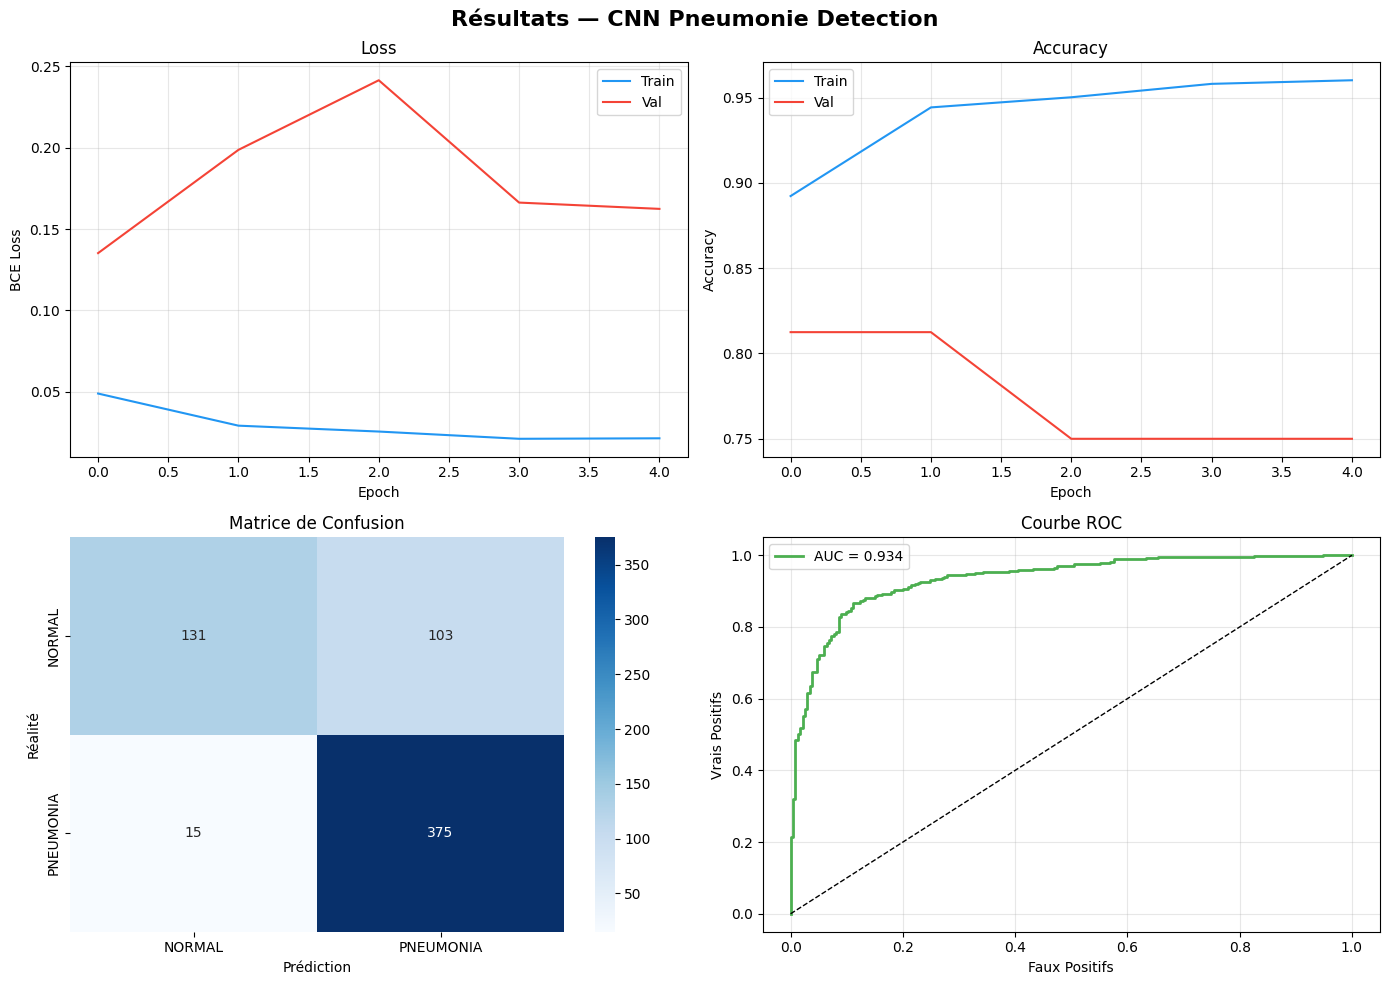


Graphiques sauvegardés → resultats_pneumonie.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Résultats — CNN Pneumonie Detection", fontsize=16, fontweight="bold")
 
# --- Courbes loss ---
ax = axes[0, 0]
ax.plot(history["train_loss"], label="Train", color="#2196F3")
ax.plot(history["val_loss"],   label="Val",   color="#F44336")
ax.set_title("Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.grid(True, alpha=0.3)
 
# --- Courbes accuracy ---
ax = axes[0, 1]
ax.plot(history["train_acc"], label="Train", color="#2196F3")
ax.plot(history["val_acc"],   label="Val",   color="#F44336")
ax.set_title("Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)
 
# --- Matrice de confusion ---
ax = axes[1, 0]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
ax.set_title("Matrice de Confusion")
ax.set_xlabel("Prédiction"); ax.set_ylabel("Réalité")
 
# --- Courbe ROC ---
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color="#4CAF50", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Courbe ROC")
ax.set_xlabel("Faux Positifs"); ax.set_ylabel("Vrais Positifs")
ax.legend(); ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("resultats_pneumonie.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGraphiques sauvegardés → resultats_pneumonie.png")
 

### Choix du seuil de décision

Aprés avoir testé plusieurs valeurs de seuil, j'ai comparé le nombre de vrais positifs, faux positifs et faux négatifs. Le seuil choisi influence directement le compromis entre sensibilité et spécificité.

| Seuil | Pneumonies bien détectées | Normaux bien détectés | Pneumonies ratées | Normaux classés pneumonie | Commentaire |
|---|---:|---:|---:|---:|---|
| 0.35 | 383 | 106 | 7 | 128 | Trop de faux positifs |
| 0.40 | 379 | 151 | 11 | 83 | Encore beaucoup de faux positifs |
| 0.45 | 367 | 170 | 23 | 64 | Plus équilibré, mais plus de pneumonies ratées |
| 0.50 | 357 | 188 | 33 | 46 | Seuil classique, mais moins sensible |
| 0.55 | 348 | 202 | 42 | 32 | Compromis retenu |
| 0.60 | 332 | 208 | 58 | 26 | Moins de faux positifs, mais plus de faux négatifs |
| 0.65 | 308 | 215 | 82 | 19 | Trop de pneumonies manquées |


En contexte médical, il est généralement plus grave de manquer une pneumonie que de signaler une image normale comme suspecte. Le seuil `0.55` est donc retenu comme compromis : il limite les faux positifs tout en gardant une bonne détection de la classe `PNEUMONIA`.

Les résultats finaux montrent une AUC-ROC élevée, ce qui indique que le modèle sépare bien les deux classes. La matrice de confusion montre cependant que le modèle reste plus sensible à la pneumonie qu'à la classe normale.


### 9. Inférence sur une nouvelle image

Cette derniére fonction permet d'utiliser le modèle entrainé sur une nouvelle radio. Elle applique les memes transformations que pendant l'évaluation, calcule la probabilité de pneumonie, puis retourne la classe prédite : `NORMAL` ou `PNEUMONIA`.


In [19]:
from PIL import Image
 
def predict(image_path: str, threshold: float = DECISION_THRESHOLD) -> dict:
    """
    Prédit si une radio montre une pneumonie.
    
    Args:
        image_path : chemin vers l'image
        threshold  : seuil de décision (choisit :0.55)
    
    Returns:
        dict avec label, probabilité et confiance
    """
    img = Image.open(image_path).convert("RGB")
    tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
 
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()
 
    label = "PNEUMONIA" if prob >= threshold else "NORMAL"
    return {
        "label":       label,
        "probability": round(prob, 4),
        "confidence":  round(max(prob, 1 - prob) * 100, 1)
    }
 
# ── TEST avec une image NORMALE ──
result = predict("./chest_xray/test/NORMAL/IM-0001-0001.jpeg" )
print(f"Image NORMALE    → prédit : {result['label']} ({result['confidence']}% confiance)")

# ── TEST avec une image PNEUMONIE ──
result = predict("./chest_xray/test/PNEUMONIA/person1_virus_6.jpeg")
print(f"Image PNEUMONIE  → prédit : {result['label']} ({result['confidence']}% confiance)")


Image NORMALE    → prédit : NORMAL (51.8% confiance)
Image PNEUMONIE  → prédit : PNEUMONIA (99.3% confiance)


### Conclusion

Le modèle CNN obtient une bonne capacité de détection de la pneumonie, avec une AUC-ROC élevée. La matrice de confusion montre que le modèle détecte très bien la classe PNEUMONIA, avec très peu de pneumonies manquées. Cependant, il produit encore des faux positifs sur la classe NORMAL. Ce comportement reste acceptable dans un contexte médical exploratoire, car il est généralement préférable de signaler un cas suspect plutôt que de manquer une pneumonie.


### Pistes d'amélioration

Malheureusement, en raison de la contrainte de temps liée au délai de 10 jours, nous n'avons pas pu réduire davantage le nombre de faux positifs sur la classe `NORMAL`.

Cette limite pourrait constituer une piste d'amélioration. Il serait possible de modifier le seuil de décision, actuellement fixé à `0.55`, voire des valeurs plus élevées comme `0.70` ou `0.75`. Cela pourrait permettre de diminuer les faux positifs, mais avec le risque d'augmenter le nombre de pneumonies non détectées.

Une autre piste serait de tester différentes tailles d'images, par exemple `64x64`, afin d'évaluer l'impact de la résolution sur le temps d'entraînement et les performances du modèle, mais qui pourait induire en erreur en ratant certais details importants des radios.


# REMARQUE !
Avant ce resultat là, en entrainant le modèle j'ai reussi a avoir de meilleur resultat que celle présenté avant, `seulement 2 faux positif pour PNEUMONIA`. Malheuresement, y a eu un probleme technique de sauvegarde qui a fait que je n'ai pas garder les anciens resulats. En deep learning c'est normal de pas avoir le meme resultat à chaque entrainement car il ne suit pas le meme chemin d'apprentissage. 

![Capture d'écran 2026-04-27 183716.png](<attachment:Capture d'écran 2026-04-27 183716.png>)
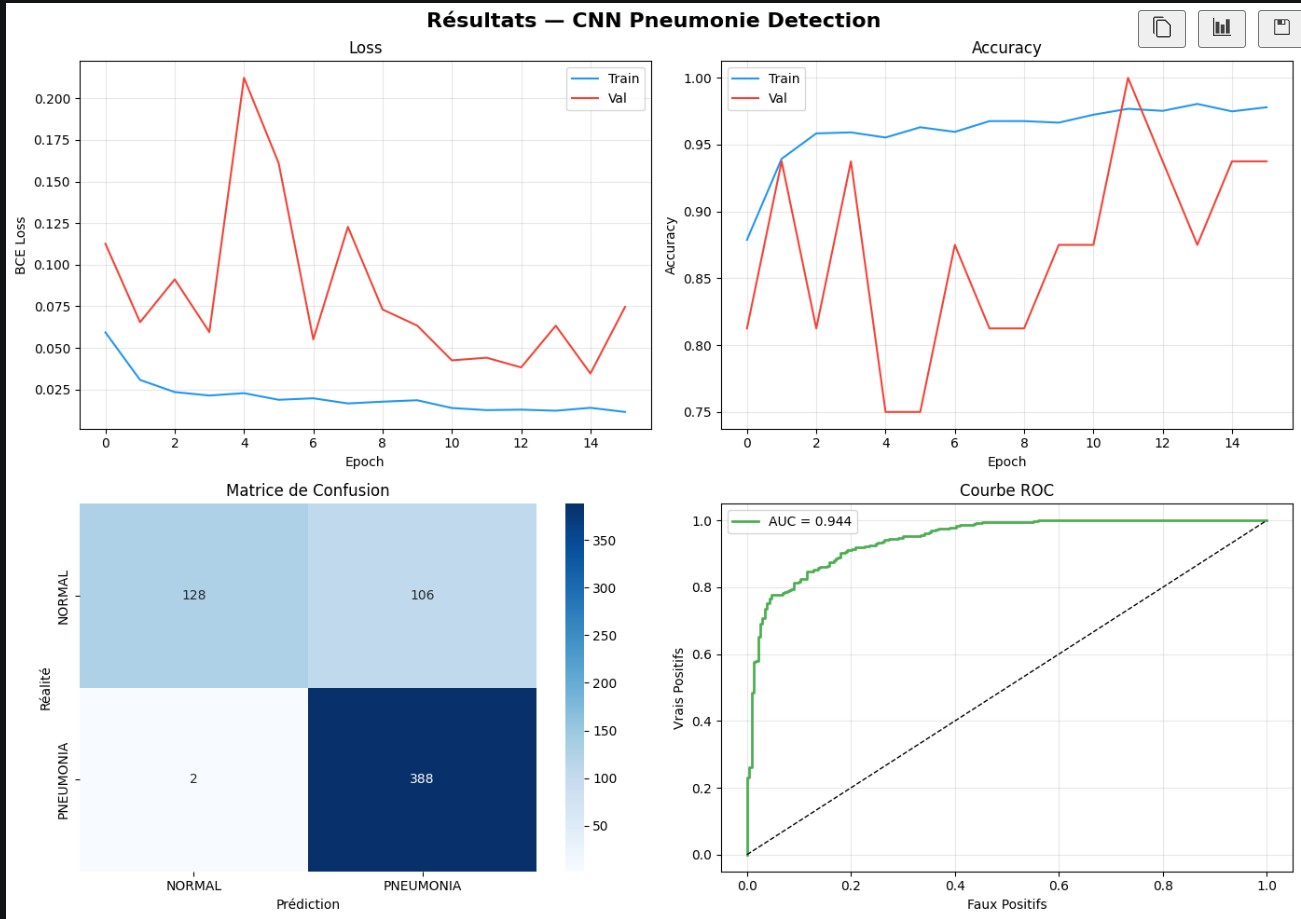